# Notebook with code to normalize trajectories

This notebook is conceived to show some methods to normalize raw trajectories. A first method is to normalize by floor, and a second is to normalize entire trajectories. 
This notebook also shows how to obtain semantic information of trajectories.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import movingpandas as mpd
import matplotlib.pyplot as plt
import os
import math
from shapely.geometry import Point, LineString

from geopandas import GeoDataFrame, read_file
from shapely.geometry import Point, LineString
from datetime import timedelta


import warnings

warnings.filterwarnings("ignore")
mpd.show_versions()

d:\programFiles\Anaconda\envs\env_alternance\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)



MovingPandas 0.22.3

SYSTEM INFO
-----------
python     : 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
executable : d:\programFiles\Anaconda\envs\env_alternance\python.exe
machine    : Windows-10-10.0.19045-SP0

PROJ INFO
-----------
PROJ       : 9.3.1
PROJ data dir: D:\programFiles\Anaconda\envs\env_alternance\Library\share\proj

PYTHON DEPENDENCIES
-------------------
numpy      : 2.0.1
geopandas  : 1.0.1
geopy      : 2.4.1
geoviews   : None
holoviews  : None
hvplot     : None
mapclassify: 2.4.3
matplotlib : 3.10.0
pandas     : 2.2.3
pyproj     : 3.6.1
shapely    : 2.0.6
stonesoup  : None


In [2]:
#Files and folders for the treatment
folder_traj_raw="../data/raw_trajectories/"
folder_traj_normalized = "../data/normalized_trajectories/"
all_traj_file_raw="all_trajectories_raw.csv"
folder_items_beg="../data/start_obs_artworks/"
folder_items_end="../data/end_obs_artworks/"
folder_items= os.listdir(folder_items_beg)
folder_itemsEnd= os.listdir(folder_items_end)
all_traj_raw = os.listdir(folder_traj_raw) 


all_traj_df=pd.DataFrame(columns=["trajectory_id","timestamp","x","y","floorNumber","itemsBegDoc","itemsEndDoc"])


#Visitor ids
names_users = {folder[11:-4] :folder for folder in all_traj_raw}

#One file with all trajectories
for file_item in folder_items:   
    name_user=file_item[6:-4]
    #Finding the corresponding files
    if name_user in names_users.keys():
        file_traj = names_users[name_user]
        fileTrajpath = os.path.join(folder_traj_raw, file_traj)
        fileItemPath = os.path.join(folder_items_beg, file_item)
        fileItemEndPath = os.path.join(folder_items_end,file_item[:-4]+"_end.csv")
        with open(fileTrajpath, 'r') as file1:
            #transform list of items and trajectories to dataframes
            traj = pd.read_csv(file1)
            name_user_form=fileTrajpath[36:-4].replace("-", "")
            traj["trajectory_id"] = int(name_user_form)
            #Begin of the trajectory at timestamp 0
            traj.timestamp=traj.timestamp - traj.timestamp.min()
            all_traj_df=pd.concat([all_traj_df, traj], ignore_index=True)

all_traj_df.to_csv(all_traj_file_raw,index=False)
all_traj_df.head()


,trajectory_id,timestamp,x,y,floorNumber,itemsBegDoc,itemsEndDoc
0,201902181020,0.000000,2611.339649,4703.756536,0,NaN,NaN
1,201902181020,1.615955,2470.503354,4629.948437,0,NaN,NaN
2,201902181020,2.528586,2436.970902,4589.689475,0,NaN,NaN
3,201902181020,3.216006,2416.851431,4529.301031,0,NaN,NaN
4,201902181020,5.048462,2336.373548,4509.171549,0,NaN,NaN


In [3]:
#Formating dataframe for MovingPandas use.
df_traj_clean = pd.read_csv(all_traj_file_raw)
df_traj_clean = df_traj_clean.rename(columns={'x': 'X', 'y': 'Y','timestamp':"t"})
df_traj_clean.head()

,trajectory_id,t,X,Y,floorNumber,itemsBegDoc,itemsEndDoc
0,201902181020,0.000000,2611.339649,4703.756536,0,NaN,NaN
1,201902181020,1.615955,2470.503354,4629.948437,0,NaN,NaN
2,201902181020,2.528586,2436.970902,4589.689475,0,NaN,NaN
3,201902181020,3.216006,2416.851431,4529.301031,0,NaN,NaN
4,201902181020,5.048462,2336.373548,4509.171549,0,NaN,NaN


## Obtaining normalized trajectories for each floor

In [4]:
#Obtaining trajectories for each floor to separate each treatment 
df_traj_floor0= df_traj_clean[df_traj_clean.floorNumber==0]
df_traj_floor1= df_traj_clean[df_traj_clean.floorNumber==1]
df_traj_floor2= df_traj_clean[df_traj_clean.floorNumber==2]

print(len(df_traj_floor0.trajectory_id.unique()))
print(len(df_traj_floor1.trajectory_id.unique()))
print(len(df_traj_floor2.trajectory_id.unique()))

51
50
40


In [5]:
#Obtaining dataframes of trajectories for each floor and each time window, then find the moment when the floor is the most visited

dataf_0_long=pd.DataFrame()
dataf_1_long=pd.DataFrame()
dataf_2_long=pd.DataFrame()
trajs=[]

#ground floor treatment
for user in df_traj_floor0.trajectory_id.unique():
    #We get the trajectory for each user
    df_traj=df_traj_floor0[df_traj_floor0.trajectory_id==user].reset_index()
    #Calculate the difference between two timestamps
    df_traj['Diff'] = df_traj['t'].diff().fillna(0)
    #Threshold of 8 minutes to get time windows where floors are visited
    threshold = 480
    #Find indices to split the dataframes and get trajectory for each time window
    split_indices = df_traj.index[df_traj['Diff'] > threshold].tolist()
    split_indices = [0] + split_indices + [len(df_traj)]
    #Dataframes containing each trajectory for each time window
    dataframes_splits = [df_traj.iloc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]
    max_duration=0
    #Put timestamps to 0 for each dataframe to delete biases on time
    #We get the longest trajectories for each floor
    for dataf in dataframes_splits:
        dataf.t=dataf.t - dataf.t.min()
        if (dataf.iloc[-1].t >max_duration):
            max_duration=dataf.iloc[-1].t
            dataf_long=dataf

    dataf_0_long = pd.concat([dataf_0_long, dataf_long], ignore_index=True)

#First floor treatment 
for user in df_traj_floor1.trajectory_id.unique():
    df_traj=df_traj_floor1[df_traj_floor1.trajectory_id==user].reset_index()
    df_traj['Diff'] = df_traj['t'].diff().fillna(0)
    threshold = 480
    split_indices = df_traj.index[df_traj['Diff'] > threshold].tolist()
    split_indices = [0] + split_indices + [len(df_traj)]
    dataframes_splits = [df_traj.iloc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]
    max_duration=0
    for dataf in dataframes_splits:
        dataf.t=dataf.t - dataf.t.min()
        if (dataf.iloc[-1].t >max_duration):
            max_duration=dataf.iloc[-1].t
            dataf_long=dataf

    dataf_1_long = pd.concat([dataf_1_long, dataf_long], ignore_index=True)

#Second floor treatment
for user in df_traj_floor2.trajectory_id.unique():
    df_traj=df_traj_floor2[df_traj_floor2.trajectory_id==user].reset_index()
    df_traj['Diff'] = df_traj['t'].diff().fillna(0)
    threshold = 480
    split_indices = df_traj.index[df_traj['Diff'] > threshold].tolist()
    split_indices = [0] + split_indices + [len(df_traj)]
    dataframes_splits = [df_traj.iloc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]
    max_duration=0
    for dataf in dataframes_splits:
        dataf.t=dataf.t - dataf.t.min()
        if (dataf.iloc[-1].t >max_duration):
            max_duration=dataf.iloc[-1].t
            dataf_long=dataf

    dataf_2_long = pd.concat([dataf_2_long, dataf_long], ignore_index=True)

trajs_long=[dataf_0_long,dataf_1_long,dataf_2_long]

In [6]:
#Obtain a trajectory Collection for each floor 
trajs_coll=[]
#Only get the longest trajectories for each floor
for trajs in trajs_long:
    trajs.insert(0,"timestamp",pd.to_datetime(trajs['t'],unit='s'))
    trajs=trajs.drop("t",axis=1)
    trajs = trajs.sort_values(by='timestamp')
    gdf = gpd.GeoDataFrame(trajs, geometry=gpd.points_from_xy(trajs['X'], trajs['Y']))
    traj_collection_raw = mpd.TrajectoryCollection(gdf, 'trajectory_id', t="timestamp",x="X",y="Y")
    print(traj_collection_raw)
    trajs_coll.append(traj_collection_raw)

print(trajs_coll)

TrajectoryCollection with 51 trajectories
TrajectoryCollection with 50 trajectories
TrajectoryCollection with 40 trajectories
[TrajectoryCollection with 51 trajectories, TrajectoryCollection with 50 trajectories, TrajectoryCollection with 40 trajectories]


In [7]:
#Smoothing the trajectories with a time gap of two seconds between each point
gap=2
trajs_coll_normalized=[]

#We work on each collection for each floor
for traj_collection in trajs_coll:
    trajectories_normalized_sec=[]
    #For each trajectory (user) in the collection
    for traj in traj_collection.trajectories:
        new_traj_df=pd.DataFrame(columns=["geometry","t","x","y"])
        #We get the last timestamp of the trajectory 
        end_time=traj.get_end_time()
        #We get the duration of the trajectory
        nb_seconds=(end_time - pd.Timestamp(0)).total_seconds()
        #And the beginning
        start_time=traj.get_start_time()
        id_traj=traj.id
        for i in range (0,int(nb_seconds)+1,gap):
            #Using interpolation to get the position at a specific timestamp (every gap seconds)
            point=traj.interpolate_position_at(start_time)
            new_traj_df.loc[len(new_traj_df)] = {"geometry":point,"t":start_time, "x":point.x,"y":point.y}
            #We iterate over the gap until the end of the trajectory
            start_time+=pd.Timedelta(seconds=gap)
        print(id_traj)
        gdf=GeoDataFrame(new_traj_df)
        #Getting the normalized trajectory
        new_traj= mpd.Trajectory(gdf,traj_id=id_traj, traj_id_col="trajectory_id",t='t',x="x",y="y")
        trajectories_normalized_sec.append(new_traj)

    trajs_normalized_sec = mpd.TrajectoryCollection(trajectories_normalized_sec, "trajectory_id",t='t',x='x',y="y")
    trajs_coll_normalized.append(trajs_normalized_sec)
print(trajs_coll_normalized)


201902181020
201902181200
201902181210
201902181410
201902181600
201902181610
201902201020
201902201210
201902201400
201902201410
201902201600
201902201610
201902211210
201902211400
201902211600
201902211610
201902211700
201902211710
201902221020
201902221200
201902221210
201902221400
201902221410
201902221600
201902221610
201902231200
201902251200
201903011010
201903011020
201903011600
201903021410
201903021610
201903041020
201903041600
201903061400
201903061410
201903061610
201903081400
201903081410
201903081610
201903091010
201903091200
201903091210
201903091410
201903091600
201903111400
201903181610
201903201010
201903201020
201903211400
201903211410
201902181020
201902181200
201902181210
201902181410
201902181600
201902181610
201902201210
201902201400
201902201410
201902201600
201902201610
201902211210
201902211400
201902211600
201902211610
201902211700
201902211710
201902221020
201902221200
201902221210
201902221400
201902221410
201902221600
201902221610
201902231200
201902251200

In [8]:
traj_example = trajs_coll_normalized[0].trajectories[1]

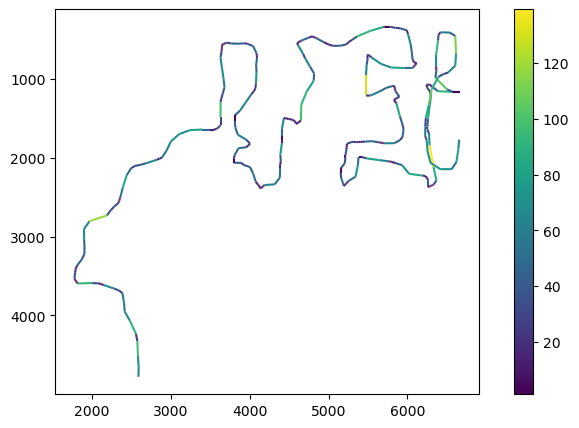

In [9]:
#Print an example (ground floor) of the normalized trajectories
ax = traj_example.plot(column='speed', legend=True, figsize=(9, 5))
ax.invert_yaxis()  
plt.show()

## Obtaining entire normalized trajectories


In [10]:
#Getting the whole trajectory in a format understandable by moving pandas
df_traj_clean.insert(0,"timestamp",pd.to_datetime(df_traj_clean['t'],unit='s'))
df_traj_clean=df_traj_clean.drop("t",axis=1)
df_traj_clean = df_traj_clean.sort_values(by='timestamp')

gdf = gpd.GeoDataFrame(df_traj_clean, geometry=gpd.points_from_xy(df_traj_clean['X'], df_traj_clean['Y']))
traj_collection_gen_entire = mpd.TrajectoryCollection(gdf, 'trajectory_id', t="timestamp",x="X",y="Y")
print(traj_collection_gen_entire)

TrajectoryCollection with 51 trajectories


In [11]:
#Normalizing the trajectories
gap=2
trajectories_normalized_sec=[]
#For each trajectory (user) in the collection
for traj in traj_collection_gen_entire.trajectories:
    new_traj_df=pd.DataFrame(columns=["geometry","t","x","y"])
    #We get the last timestamp of the trajectory 
    end_time=traj.get_end_time()
    #We get the duration of the trajectory
    nb_seconds=(end_time - pd.Timestamp(0)).total_seconds()
    #And the beginning
    start_time=traj.get_start_time()
    id_traj=traj.id
    for i in range (0,int(nb_seconds)+1,gap):
        #Using interpolation to get the position at a specific timestamp (every gap seconds)
        point=traj.interpolate_position_at(start_time)
        new_traj_df.loc[len(new_traj_df)] = {"geometry":point,"t":start_time, "x":point.x,"y":point.y}
        #We iterate over the gap until the end of the trajectory
        start_time+=pd.Timedelta(seconds=gap)
    print(id_traj)
    gdf=GeoDataFrame(new_traj_df)
    #Getting the normalized trajectory
    new_traj= mpd.Trajectory(gdf,traj_id=id_traj, traj_id_col="trajectory_id",t='t',x="x",y="y")
    trajectories_normalized_sec.append(new_traj)

entiretrajs_normalized_mp= mpd.TrajectoryCollection(trajectories_normalized_sec, "trajectory_id",t='t',x='x',y="y")

201902181020
201902181200
201902181210
201902181410
201902181600
201902181610
201902201020
201902201210
201902201400
201902201410
201902201600
201902201610
201902211210
201902211400
201902211600
201902211610
201902211700
201902211710
201902221020
201902221200
201902221210
201902221400
201902221410
201902221600
201902221610
201902231200
201902251200
201903011010
201903011020
201903011600
201903021410
201903021610
201903041020
201903041600
201903061400
201903061410
201903061610
201903081400
201903081410
201903081610
201903091010
201903091200
201903091210
201903091410
201903091600
201903111400
201903181610
201903201010
201903201020
201903211400
201903211410


In [12]:
#Getting the floor number for each visitor position 

def applyFloor (row, user_raw):
    idx = (user_raw['timestamp'] - row['t']).abs().idxmin()
    return (int(user_raw.loc[idx].floorNumber))

df_entiretrajs_normalized=entiretrajs_normalized_mp.to_point_gdf()
df_entiretrajs_normalized = df_entiretrajs_normalized.reset_index()
df_entiretrajs_normalized['t'] = (df_entiretrajs_normalized['t'] - df_entiretrajs_normalized['t'].iloc[0]).dt.total_seconds()

for id in df_entiretrajs_normalized.trajectory_id.unique():
    visitor=df_entiretrajs_normalized[df_entiretrajs_normalized.trajectory_id==id]
    raw_traj_visitor = pd.read_csv(folder_traj_raw+"trajectory_"+str(id)+".csv")
    visitor['floorNumber'] = visitor.apply(lambda row : applyFloor(row, raw_traj_visitor), axis=1)
    visitor = visitor.rename(columns = {"t":"timestamp"})
    visitor.drop(["trajectory_id", "geometry"], axis=1, inplace= True)
    #Saving normalized trajectories
    visitor.to_csv(folder_traj_normalized+str(id)+"_traj_normalized.csv", index=False)


## Obtaining semantic information about trajectories

In [13]:
# obtaining the position of the walls
import json
file_path = '../data/NMFA_3floors_plan.json'
with open(file_path, 'r') as file:
    data = json.load(file)
walls_0 = data['floors'][0]['walls']
walls_1 = data['floors'][1]['walls']
walls_2 = data['floors'][2]['walls']


df_walls_0 = pd.DataFrame()
df_walls_1= pd.DataFrame()
df_walls_2= pd.DataFrame()

#Position for each wall for each floor
for wall in walls_0: 
    lgn_df=pd.DataFrame({'id':[wall['id']], 'begx':[wall['position'][0]['x']], 'begy':[wall['position'][0]['y']] ,"endx":[wall['position'][1]['x']], "endy":[wall['position'][1]['y']]  })
    df_walls_0 = pd.concat([df_walls_0,lgn_df], ignore_index=True)
for wall in walls_1: 
    lgn_df=pd.DataFrame({'id':[wall['id']], 'begx':[wall['position'][0]['x']], 'begy':[wall['position'][0]['y']] ,"endx":[wall['position'][1]['x']], "endy":[wall['position'][1]['y']]  })
    df_walls_1 = pd.concat([df_walls_0,lgn_df], ignore_index=True)
for wall in walls_2: 
    lgn_df=pd.DataFrame({'id':[wall['id']], 'begx':[wall['position'][0]['x']], 'begy':[wall['position'][0]['y']] ,"endx":[wall['position'][1]['x']], "endy":[wall['position'][1]['y']]  })
    df_walls_2 = pd.concat([df_walls_0,lgn_df], ignore_index=True)


df_walls_0.head()

,id,begx,begy,endx,endy
0,W0_0,2.50000,4850.3622,2.50000,4600.3622
1,W0_1,118.50758,4939.3622,118.50758,4523.3622
2,W0_2,126.00000,4405.8965,740.00000,4405.8965
3,W0_3,126.00760,5057.8967,0.00760,5057.8967
4,W0_4,126.00760,4405.8968,0.00760,4405.8968


In [14]:
#WARNING: this cell takes a lot of time to execute. 
#Distance between a wall and a position of the user
def applyWall (wall, point):
    wall_coord = LineString([(wall.begx, wall.begy),(wall.endx, wall.endy)])
    distance = point.distance(wall_coord)
    return distance

#Calculating the distance between the nearest wall and the user at a specific timestamp
def applyDistanceWalls (row, normalized_traj):
    df_dist_wall = pd.DataFrame()
    floor=int(normalized_traj[normalized_traj.timestamp==row.timestamp]["floorNumber"])
    #We take the position
    point = Point (row.x,row.y)
    #For each wall, we get the distance from the point 
    #If the visitor is on the ground floor
    if (floor ==0 ):
        df_dist_wall["Dist"] = df_walls_0.apply(lambda row : applyWall (row, point), axis=1)
    #If the visitor is on the first floor
    if (floor == 1 ):
        df_dist_wall["Dist"] = df_walls_1.apply(lambda row : applyWall (row, point), axis=1)
    #If the visitor is on the second floor
    if (floor == 2):
        df_dist_wall["Dist"] = df_walls_2.apply(lambda row : applyWall (row, point), axis=1)
    #We get the distance from the nearest wall
    min_wall = df_dist_wall["Dist"].min()
    return min_wall


df_semantic_info=pd.DataFrame(columns=["trajectory_id","duration","speed","nb_items","nb_stops","length", "distwall","curvature"])

#Adding speed
entiretrajs_normalized_mp.add_speed()
#Adding stops
detector = mpd.TrajectoryStopDetector(entiretrajs_normalized_mp)
stop_points_entire = detector.get_stop_points(
    min_duration=timedelta(seconds=20), max_diameter=300)
print(len(stop_points_entire))
stop_points_entire=stop_points_entire[stop_points_entire.duration_s<400] #we drop the irrelevant stops 
#We get the id of trajectories
stop_points_entire=stop_points_entire.reset_index()
stop_points_entire["stop_id"]=stop_points_entire['stop_id'].apply(lambda row: row[:12])

df_with_speed_stops=entiretrajs_normalized_mp.to_point_gdf()
df_with_speed_stops = df_with_speed_stops.reset_index()
df_with_speed_stops['t'] = (df_with_speed_stops['t'] - df_with_speed_stops['t'].iloc[0]).dt.total_seconds()

for traj in entiretrajs_normalized_mp.trajectories:
    #Get the duration
    duration=traj.get_duration().total_seconds()
    #Get the length of the trajectory
    length=traj.get_length()
    #Get the mean speed
    mean_speed = df_with_speed_stops[df_with_speed_stops.trajectory_id==traj.id]['speed'].mean()
    #Get the number of stops
    nb_stops=stop_points_entire[stop_points_entire.stop_id==str(traj.id)].shape[0]
    #Get the mean distance from the walls
    traj_normalized = pd.read_csv(folder_traj_normalized+str(traj.id)+"_traj_normalized.csv")
    traj_normalized['dist_walls'] = traj_normalized.apply(lambda row: applyDistanceWalls(row, traj_normalized), axis=1)
    dist_wall=traj_normalized["dist_walls"].mean()
    #Get the curvature
    dx = np.gradient(traj_normalized.x)
    dy = np.gradient(traj_normalized.y)
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    curvature = np.abs(dx * d2y - dy * d2x) / ((dx**2 + dy**2)**1.5)
    
    average_curvature = np.mean(curvature)
    if math.isnan(average_curvature):
        average_curvature=0

    new_traj={"trajectory_id":str(traj.id),"duration":duration,"speed":mean_speed,"nb_stops":nb_stops,"length":length, "distwall":dist_wall, "curvature":average_curvature}
    #dataframe for each trajectory
    df_semantic_info.loc[len(df_semantic_info)]=new_traj

df_semantic_info.head()

2805


,trajectory_id,duration,speed,nb_items,nb_stops,length,distwall,curvature
0,201902181020,3704.0,17.244834,NaN,56,63729.789580,186.948068,0.038783
1,201902181200,2948.0,32.334112,NaN,42,95257.544128,167.649512,0.174906
2,201902181210,2948.0,32.793737,NaN,39,96566.818958,171.266685,0.144522
3,201902181410,3696.0,24.988200,NaN,79,92159.278191,166.745664,0.029800
4,201902181600,4836.0,18.148534,NaN,92,87735.324794,209.252325,0.111875


In [17]:
#Getting the number of items seen for each trajectory
for file_item in folder_items:   
    name_user=file_item[6:-4]
    items = pd.read_csv(folder_items_beg +file_item)
    df_semantic_info.loc[df_semantic_info['trajectory_id'] == name_user, 'nb_items']=len(items)

In [18]:
df_semantic_info.head()

,trajectory_id,duration,speed,nb_items,nb_stops,length,distwall,curvature
0,201902181020,3704.0,17.244834,116.0,56,63729.789580,186.948068,0.038783
1,201902181200,2948.0,32.334112,95.0,42,95257.544128,167.649512,0.174906
2,201902181210,2948.0,32.793737,96.0,39,96566.818958,171.266685,0.144522
3,201902181410,3696.0,24.988200,237.0,79,92159.278191,166.745664,0.029800
4,201902181600,4836.0,18.148534,196.0,92,87735.324794,209.252325,0.111875
